In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Mengambil dataset Adult Income dari OpenML

from sklearn.datasets import fetch_openml

adult = fetch_openml(
    name="adult",
    version=2,
    as_frame=True
)

df = adult.frame.copy()

print("Ukuran dataset:", df.shape)

display(df.head())

Ukuran dataset: (48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [ ]:
print(df["sex"].unique())
print(df["race"].unique())
print(df["class"].unique())

['Male', 'Female']
Categories (2, object): ['Female', 'Male']
['Black', 'White', 'Asian-Pac-Islander', 'Other', 'Amer-Indian-Eskimo']
Categories (5, object): ['Amer-Indian-Eskimo', 'Asian-Pac-Islander', 'Black', 'Other', 'White']
['<=50K', '>50K']
Categories (2, object): ['<=50K', '>50K']


In [ ]:
# Membersihkan data yang memiliki missing value

df = df.dropna().copy()

# Menghilangkan spasi tambahan pada data bertipe teks
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

print("Jumlah data setelah dibersihkan:", len(df))

Jumlah data setelah dibersihkan: 45222


In [ ]:
# Membuat kolom baru:
# True  = penghasilan >50K
# False = penghasilan <=50K

df["income_over_50k"] = df["class"] == ">50K"

display(
    df[["sex", "race", "class", "income_over_50k"]].head()
)

,sex,race,class,income_over_50k
0,Male,Black,<=50K,False
1,Male,White,<=50K,False
2,Male,White,>50K,True
3,Male,Black,>50K,True
5,Male,White,<=50K,False


In [ ]:
# Menghitung persentase orang dengan pendapatan >50K berdasarkan gender

gender_income = (
    df.groupby("sex")["income_over_50k"]
    .mean()
    .mul(100)
    .reset_index(name="percentage_over_50k")
)

print("Persentase penghasilan >50K berdasarkan gender:")
display(gender_income)

Persentase penghasilan >50K berdasarkan gender:


/tmp/ipykernel_471/1482227344.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("sex")["income_over_50k"]


,sex,percentage_over_50k
0,Female,11.357605
1,Male,31.247748


In [ ]:
# Menghitung persentase orang dengan pendapatan >50K berdasarkan ras

race_income = (
    df.groupby("race")["income_over_50k"]
    .mean()
    .mul(100)
    .reset_index(name="percentage_over_50k")
)

print("Persentase penghasilan >50K berdasarkan ras:")
display(race_income)

Persentase penghasilan >50K berdasarkan ras:


/tmp/ipykernel_471/1946194706.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("race")["income_over_50k"]


,race,percentage_over_50k
0,Amer-Indian-Eskimo,12.183908
1,Asian-Pac-Islander,28.319263
2,Black,12.630085
3,Other,12.747875
4,White,26.237051


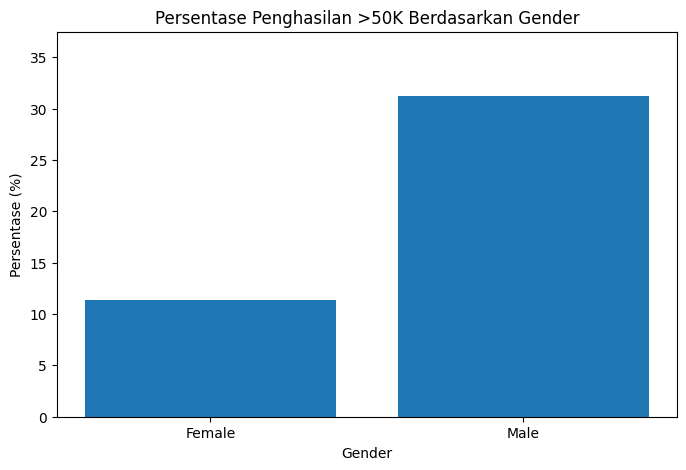

In [ ]:
# Grafik 1: Persentase >50K berdasarkan gender

plt.figure(figsize=(8, 5))

plt.bar(
    gender_income["sex"],
    gender_income["percentage_over_50k"]
)

plt.title("Persentase Penghasilan >50K Berdasarkan Gender")
plt.xlabel("Gender")
plt.ylabel("Persentase (%)")

plt.ylim(0, max(gender_income["percentage_over_50k"]) * 1.2)

plt.show()

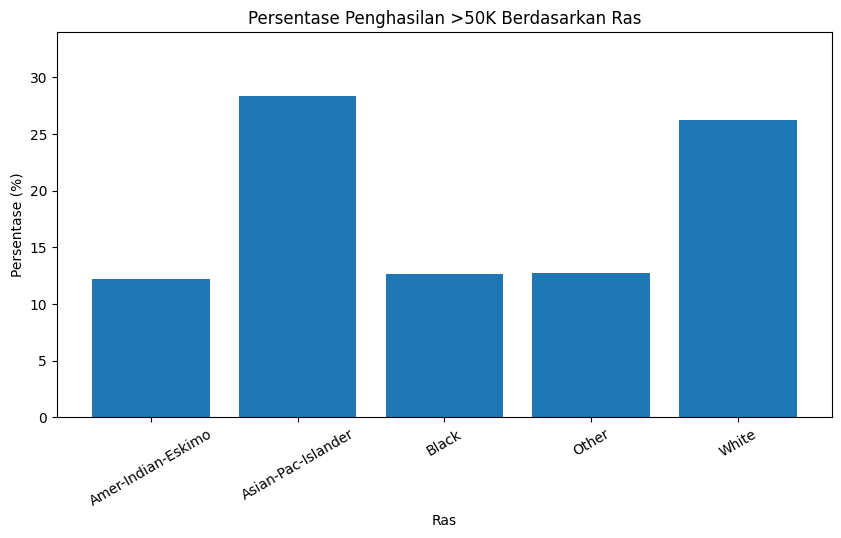

In [ ]:
# Grafik 2: Persentase >50K berdasarkan ras

plt.figure(figsize=(10, 5))

plt.bar(
    race_income["race"],
    race_income["percentage_over_50k"]
)

plt.title("Persentase Penghasilan >50K Berdasarkan Ras")
plt.xlabel("Ras")
plt.ylabel("Persentase (%)")

plt.xticks(rotation=30)
plt.ylim(0, max(race_income["percentage_over_50k"]) * 1.2)

plt.show()

In [ ]:
# Menghitung persentase >50K berdasarkan gender dan ras

gender_race_income = (
    df.groupby(["race", "sex"])["income_over_50k"]
    .mean()
    .mul(100)
    .reset_index(name="percentage_over_50k")
)

display(gender_race_income)

/tmp/ipykernel_471/2225515510.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["race", "sex"])["income_over_50k"]


,race,sex,percentage_over_50k
0,Amer-Indian-Eskimo,Female,8.433735
1,Amer-Indian-Eskimo,Male,14.498141
2,Asian-Pac-Islander,Female,14.908257
3,Asian-Pac-Islander,Male,35.063437
4,Black,Female,6.046065
5,Black,Male,19.029851
6,Other,Female,7.142857
7,Other,Male,15.859031
8,White,Female,12.244383
9,White,Male,32.390822


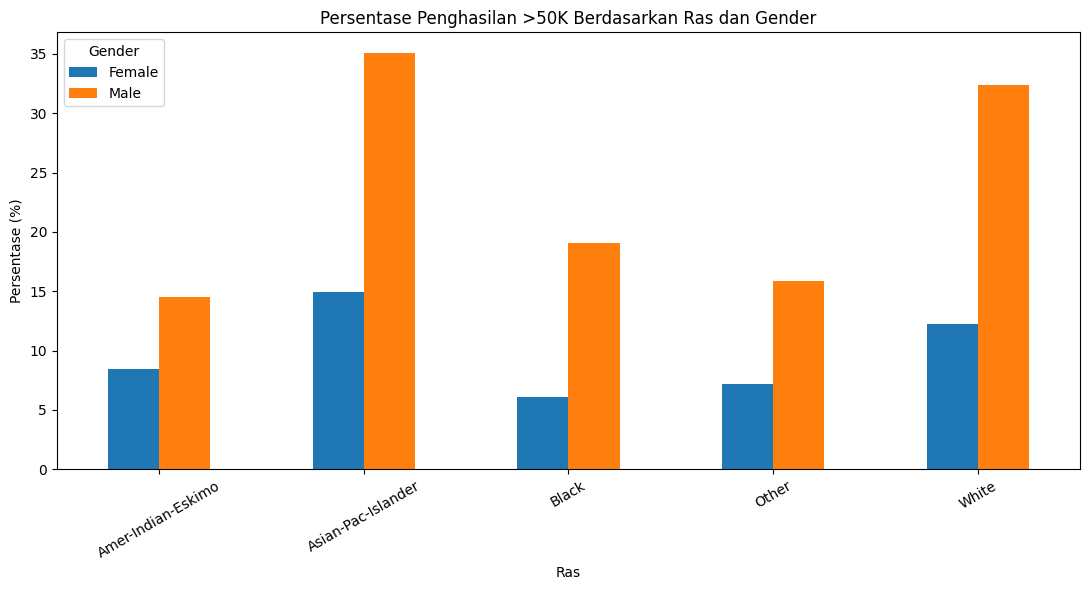

In [ ]:
# Grafik 3: Persentase >50K berdasarkan gender dan ras

pivot_data = gender_race_income.pivot(
    index="race",
    columns="sex",
    values="percentage_over_50k"
)

pivot_data.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Persentase Penghasilan >50K Berdasarkan Ras dan Gender")
plt.xlabel("Ras")
plt.ylabel("Persentase (%)")
plt.xticks(rotation=30)
plt.legend(title="Gender")

plt.tight_layout()
plt.show()

In [ ]:
# Mencari kelompok gender dengan persentase >50K tertinggi dan terendah

gender_highest = gender_income.loc[
    gender_income["percentage_over_50k"].idxmax()
]

gender_lowest = gender_income.loc[
    gender_income["percentage_over_50k"].idxmin()
]

print(
    f"Gender dengan persentase >50K tertinggi: "
    f"{gender_highest['sex']} "
    f"({gender_highest['percentage_over_50k']:.2f}%)"
)

print(
    f"Gender dengan persentase >50K terendah: "
    f"{gender_lowest['sex']} "
    f"({gender_lowest['percentage_over_50k']:.2f}%)"
)

print(
    f"Selisih persentase gender: "
    f"{gender_highest['percentage_over_50k'] - gender_lowest['percentage_over_50k']:.2f} percentage points"
)

Gender dengan persentase >50K tertinggi: Male (31.25%)
Gender dengan persentase >50K terendah: Female (11.36%)
Selisih persentase gender: 19.89 percentage points


In [ ]:
# Mencari kelompok ras dengan persentase >50K tertinggi dan terendah

race_highest = race_income.loc[
    race_income["percentage_over_50k"].idxmax()
]

race_lowest = race_income.loc[
    race_income["percentage_over_50k"].idxmin()
]

print(
    f"Ras dengan persentase >50K tertinggi: "
    f"{race_highest['race']} "
    f"({race_highest['percentage_over_50k']:.2f}%)"
)

print(
    f"Ras dengan persentase >50K terendah: "
    f"{race_lowest['race']} "
    f"({race_lowest['percentage_over_50k']:.2f}%)"
)

print(
    f"Selisih persentase antar kelompok ras: "
    f"{race_highest['percentage_over_50k'] - race_lowest['percentage_over_50k']:.2f} percentage points"
)

Ras dengan persentase >50K tertinggi: Asian-Pac-Islander (28.32%)
Ras dengan persentase >50K terendah: Amer-Indian-Eskimo (12.18%)
Selisih persentase antar kelompok ras: 16.14 percentage points
